In [39]:
import numpy as np
import xarray as xr
import os

from scipy.stats import linregress

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.feature as cfeature

import warnings
from mezcal_tools import *

warnings.filterwarnings("ignore", category=UserWarning)

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Setup

In [40]:
scenario = 'piControl'
running_mean_window = 20

lat_min = 0
lat_max = 90

lon_min = -100
lon_max = 15


PATH_SST = '../data/SST/' + scenario + '/'
PATH_AMOC = '../data/AMOC/' + scenario + '/'
PATH_saved_regressions = '../data/SST_AMOC_saved_regressions/'
PATH_saved_cross_regressions = '../data/SST_AMOC_cross_regressions_for_every_model/'

PATH_plots = '/glade/u/home/mmarkina/Plots/MEZCAL/'

model_names = ['ACCESS-CM2', 'ACCESS-ESM1-5', 'CESM2-WACCM', 'CESM2', 'CMCC-CM2-SR5', 'CMCC-ESM2', 'CNRM-CM6-1-HR',
               'CNRM-CM6-1', 'CNRM-ESM2-1', 'CanESM5-CanOE', 'CanESM5', 'GFDL-CM4', 'GFDL-ESM4', 'GISS-E2-1-G', 
               'HadGEM3-GC31-LL', 'HadGEM3-GC31-MM', 'IPSL-CM6A-LR', 'MIROC6', 'MPI-ESM1-2-HR', 'MPI-ESM1-2-LR', 
               'MRI-ESM2-0', 'NorESM2-LM', 'NorESM2-MM', 'UKESM1-0-LL']


amoc_institution_names = ['CSIRO-ARCCSS', 'CSIRO', 'NCAR', 'NCAR', 'CMCC', 'CMCC', 'CNRM-CERFACS', 
                         'CNRM-CERFACS', 'CNRM-CERFACS', 'CCCma', 'CCCma', 'NOAA-GFDL', 'NOAA-GFDL', 'NASA-GISS', 
                         'MOHC', 'MOHC', 'IPSL', 'MIROC', 'DKRZ', 'MPI-M', 
                         'MRI', 'NCC', 'NCC', 'MOHC']
                         


ens_members_appendices  = ['r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f2', 
                           'r1i1p1f2', 'r1i1p1f2', 'r1i1p2f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f2', 
                           'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 
                           'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f2']

# Impact maps

## Impact map math

We can write our reconstruction of AMOC $\tilde{x}$ at a single time as a function of contemporaneous SSTs $\mathbf{y}$ using regression weights $\mathbf{e}$ as

\begin{eqnarray}
    \tilde{x} = \mathbf{e}^\top\mathbf{y}.
\end{eqnarray}

Next define the variance of AMOC in terms of the covariance of SSTs:
\begin{eqnarray}
    \sigma^2_x&=\left<\tilde{\mathbf{x}}^\top\tilde{\mathbf{x}}\right>\\
    &=\mathbf{e}^\top\mathbf{C}_{YY}\mathbf{e}.
\end{eqnarray}

We would like to quantify impacts over the spatial domain. To do this, define a symmetric square root of $\mathbf{C}_{YY}$. Note that in practice this does not have to be explicitly computed and stored if we use e.g. the SVD.

\begin{eqnarray}
\mathbf{Y} &= \mathbf{U}\mathbf{\Lambda}\mathbf{V}^\top\\
\mathbf{C}_{YY}^{1/2} &\equiv \frac{1}{\sqrt{N_t-1}} \mathbf{U}\mathbf{\Lambda}^{1/2}\mathbf{U}^\top
\end{eqnarray}

Then substituting $\mathbf{C}_{YY} = \mathbf{C}_{YY}^{1/2}\mathbf{C}_{YY}^{1/2}$ we obtain

\begin{eqnarray}
    \sigma^2_x&=\mathbf{e}^\top\mathbf{C}_{YY}^{1/2}\mathbf{C}_{YY}^{1/2}\mathbf{e}\\
    &=\text{tr}\left(\mathbf{C}_{YY}^{1/2}\mathbf{e}\mathbf{e}^\top\mathbf{C}_{YY}^{1/2}\right)\\
    &=\sum \left(\mathbf{C}_{YY}^{1/2}\mathbf{e}\right)\odot\left(\mathbf{C}_{YY}^{1/2}\mathbf{e}\right)
\end{eqnarray}

so that the impact map is the elementwise product of $\mathbf{C}_{YY}^{1/2}\mathbf{e}$ with itself. We can check this by summing over the impact map, which should recover the AMOC variance. In practice, since AMOC variance can differ among models, it can be useful to normalize by AMOC variance such that the impact map is the variance fraction (and should sum to 1).


# Load SST and AMOC

In [41]:
running_mean_window = 20

ts_by_model = load_sst_and_amoc_timeseries(model_names, amoc_institution_names, ens_members_appendices, scenario, PATH_SST, PATH_AMOC, lat_min, lat_max, lon_min, lon_max)


In [42]:
# Smooth

smoothed_by_model = smooth_sst_and_amoc_timeseries(ts_by_model, running_mean_window)

# Compute and plot impact maps
(Right now these are just for individual models with themselves)

In [ ]:
# To do: make reconstruction objects indexed by prior / truth
# also just have a big single time series object with smoothed and unsmoothed, etc.,
# also indexed by model
# x_tilde, impact_full = 

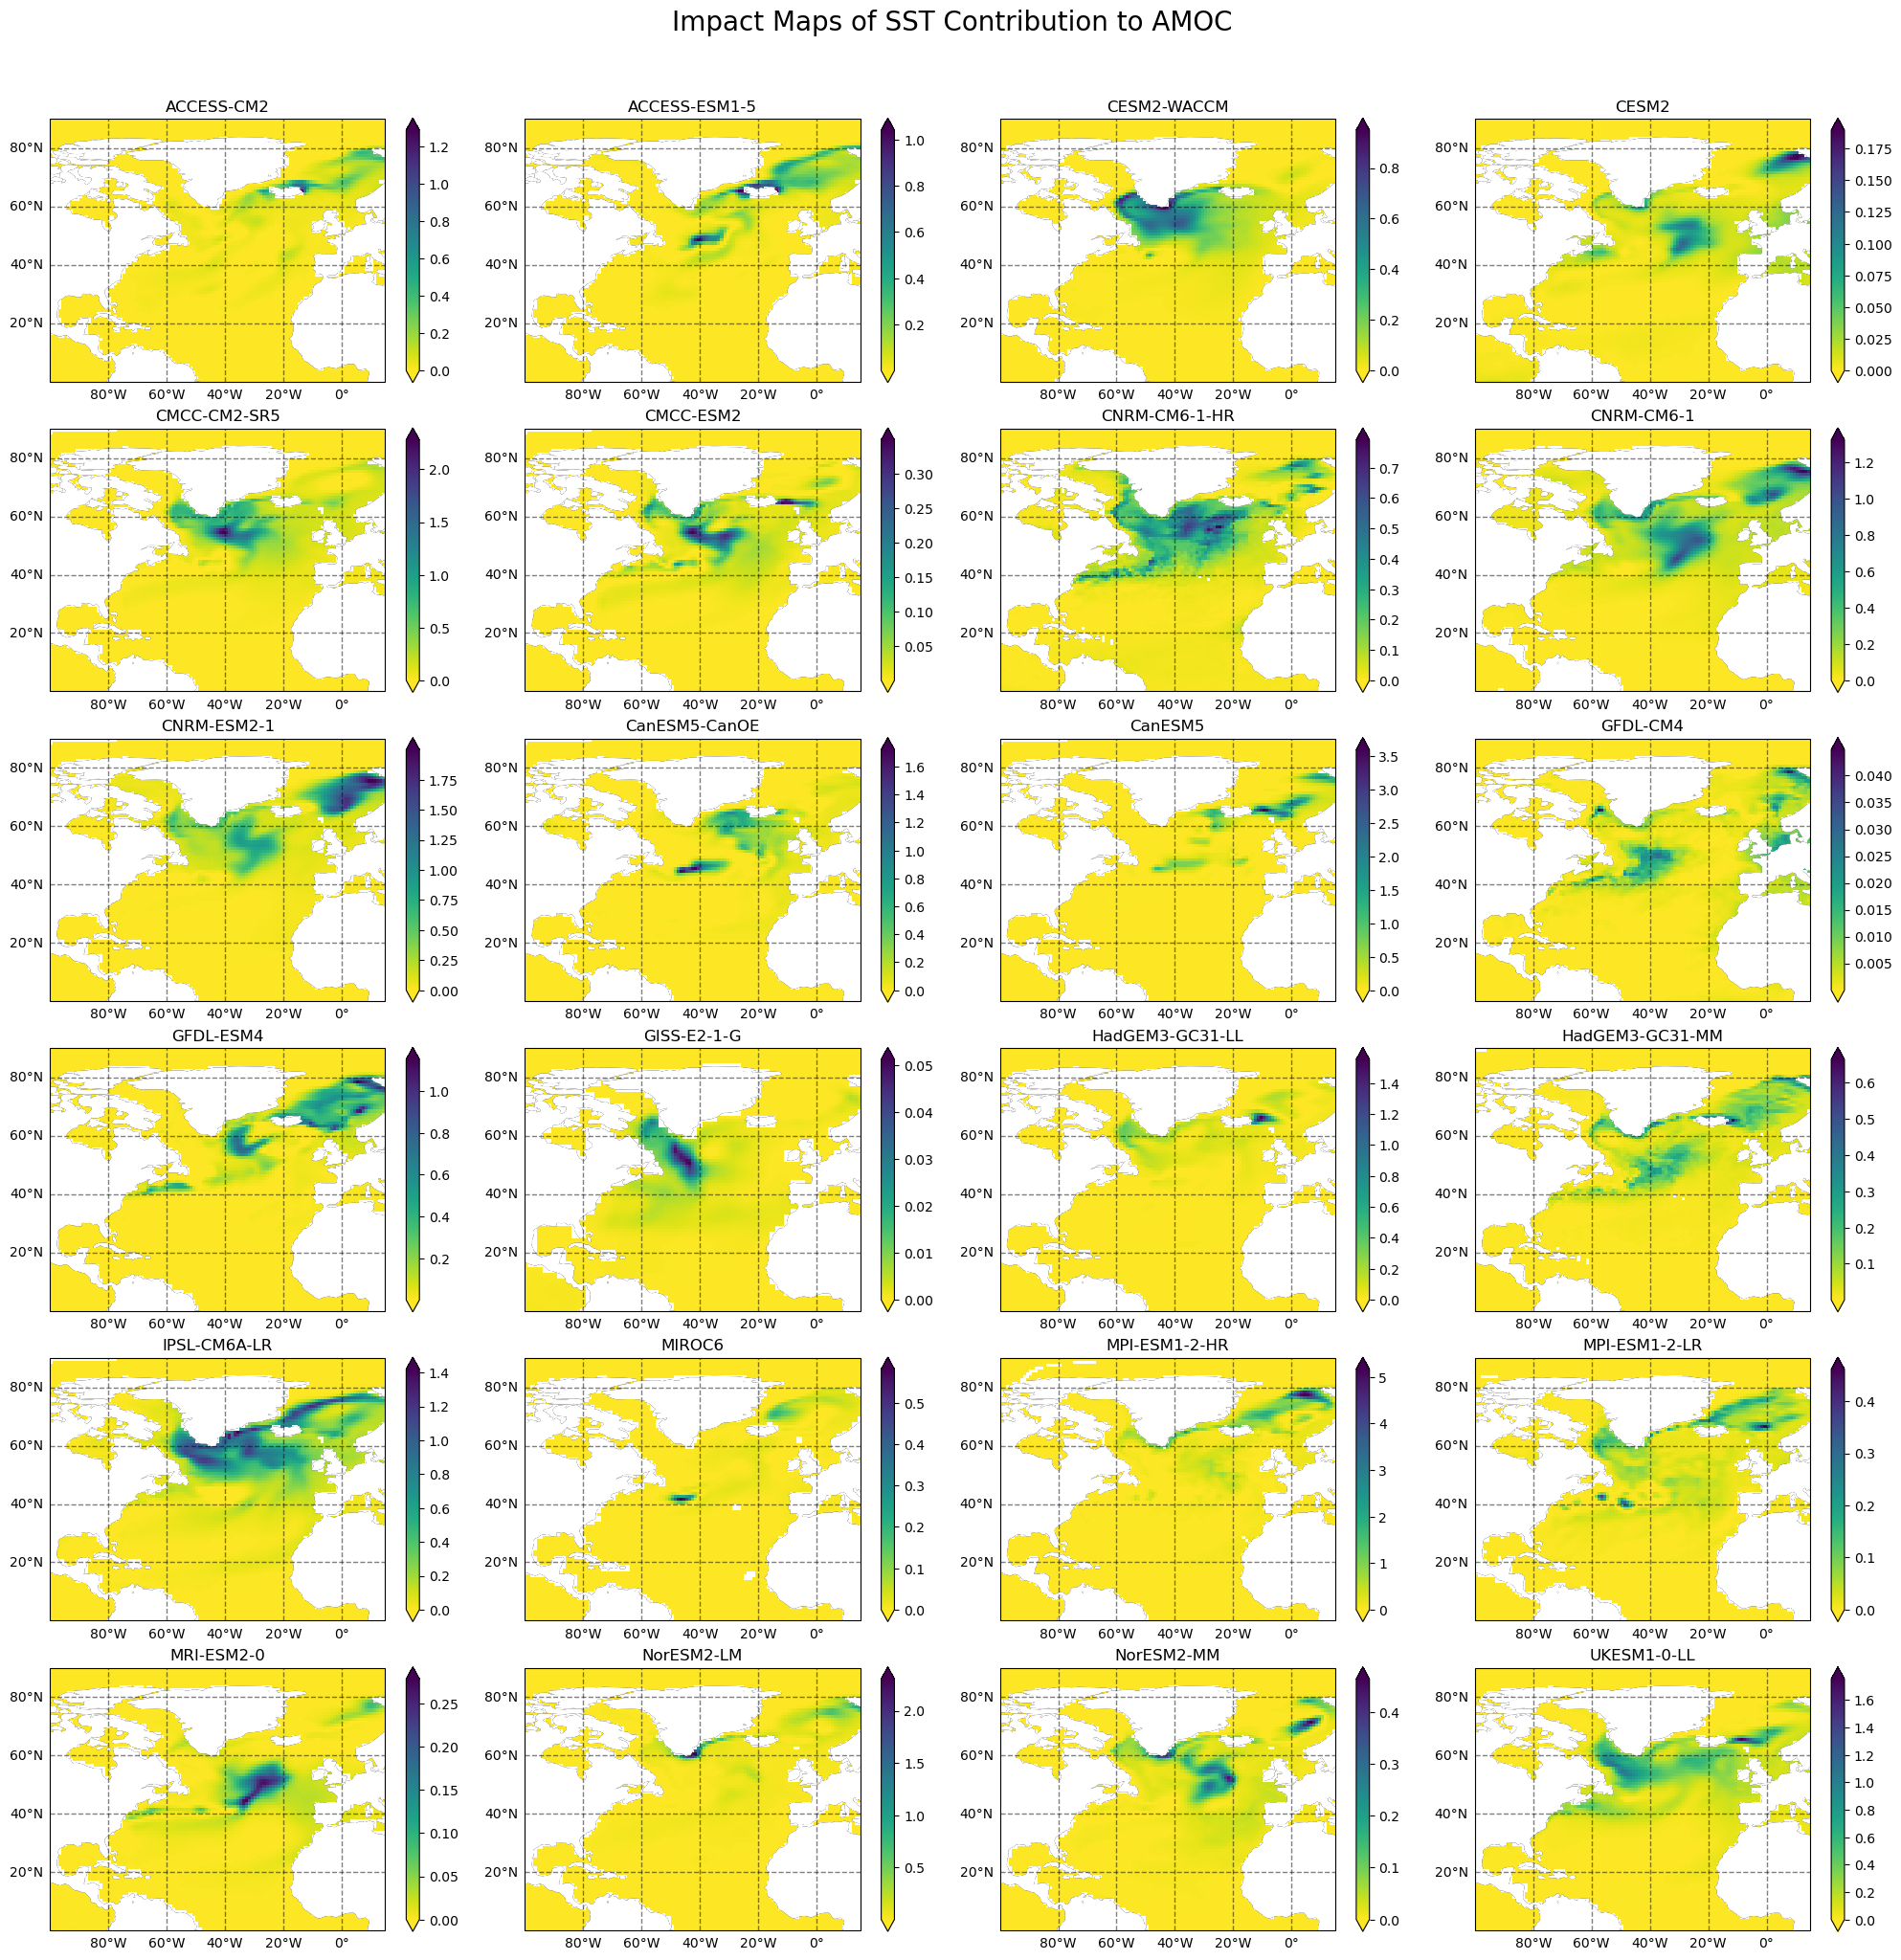

In [31]:
# Set up plot
fig, axes = plt.subplots(6, 4, figsize=(20, 20), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.ravel()

for i, (model, ts_dict) in enumerate(smoothed_by_model.items()):
    sst = ts_dict['sst']
    amoc = ts_dict['amoc']

    # Train regression and reconstruct AMOC
    f = train_reg(sst, amoc)

    # Compute and plot impact map
    ny, nx = sst.sizes['lat'], sst.sizes['lon']
    impact = compute_impact_map(f, sst, False)

    im = impact.plot.pcolormesh(
        ax=axes[i],
        transform=ccrs.PlateCarree(),
        x='lon', y='lat',
        extend='both',
        cmap='viridis_r',
        #vmax=0.005,
        add_colorbar=True,
        shading='auto'
    )

    axes[i].set_title(f"{model}")
    axes[i].coastlines()

    # Add land feature
    land = cfeature.NaturalEarthFeature(
        'physical', 'land', '110m',
        edgecolor='face', facecolor='white'
    )
    axes[i].add_feature(land)

    # Set spatial extent
    axes[i].set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

    # Gridlines
    gl = axes[i].gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=1,
        color='black',
        alpha=0.5,
        linestyle='--'
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER

# Finalize plot
fig.suptitle("Impact Maps of SST Contribution to AMOC", fontsize=20, y=1.02)
fig.tight_layout()
plt.show()